#DAY 29 - PRODUCT BASKET ANALYSIS



##Objectives:
Identify products that are frequently purchased together using Order/Invoice IDs and generate simple product recommendations.


# Day 29 - Product Basket Analysis

## Project Overview

Product Basket Analysis is used to identify products that are frequently purchased together in the same order.

In this project, the Online Retail II dataset is analyzed using Python and Pandas to discover common product combinations and generate simple product recommendations.

### Objective
- Identify frequently purchased product pairs.
- Understand customer purchasing patterns.
- Generate simple product recommendations.

### Tools Used
- Python
- Pandas
- Google Colab

### Dataset
Online Retail II

## 1.Import Libraries
## 2. Load Libraries

In [3]:
# 1. Import Libraries
import pandas as pd
import itertools
from collections import Counter

# 2. Load Dataset
df = pd.read_excel('/content/online_retail_II.xlsx')



## 3.Understand the Dataset

In [5]:
# 3. Understand the Dataset

print("\n--- First 5 Rows ---")
print(df.head())

print("\n--- Rows and Columns ---")
print(df.shape)

print("\n--- Basic Information About Dataset ---")
df.info()

print("\n--- Columns in Dataset ---")
print(df.columns)

print("\n--- Sum of Null Values in Each Column ---")
print(df.isnull().sum())



--- First 5 Rows ---
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom  

--- Rows and Columns ---
(525461, 8)

--- Basic Information About Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Col

## 4. Data Cleaning

In [18]:
## 4. Data Cleaning

df = df.dropna(subset=["Description"])
df = df[~df["Invoice"].astype(str).str.startswith("C")]
df = df[df["Quantity"] > 0]
print(df.shape)
print(df.isnull().sum())

(512033, 8)
Invoice             0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
Price               0
Customer ID    104338
Country             0
dtype: int64


### Data Cleaning Observations

After cleaning the dataset, 512,033 rows and 8 columns remained.

The missing-value check showed that Customer ID contains 104,338 missing values. Since this project focuses on product combinations within the same Invoice, Customer ID is not required for the basket analysis. Therefore, these rows were retained.

## 5. Create Order-Product Basket

### What is an Order-Product Basket?

Each invoice/order represents one customer transaction.

For every order, we collect all the products purchased together.

Example:

Order 10001:
- Bread
- Butter
- Milk

Order 10002:
- Bread
- Jam
- Milk

These products can then be compared to find frequently purchased combinations.

In [11]:
basket = df.groupby("Invoice")["Description"].apply(lambda x: list(set(x)))
display(basket.head())

# check how many orders have
print("Number of baskets:", len(basket))

,Description
Invoice,
489434,"[15CM CHRISTMAS GLASS BALL 20 LIGHTS, STRAWBER..."
489435,"[HEART MEASURING SPOONS LARGE, CAT BOWL , LUNC..."
489436,"[HEART IVORY TRELLIS LARGE, PIZZA PLATE IN BOX..."
489437,"[FELTCRAFT DOLL EMILY, CINAMMON & ORANGE WREAT..."
489438,"[JUMBO BAG CHARLIE AND LOLA TOYS, CHARLIE AND ..."


Number of baskets: 21002


## 6. Remove Single-Product Baskets

Some invoices contain only one product.

Since product-pair analysis requires at least two different products in the same transaction, invoices containing only one product are removed.

In [12]:
# Remove baskets containing only one product
basket = basket[basket.apply(len) > 1]

print("Baskets with more than one product:", len(basket))

display(basket.head())

Baskets with more than one product: 18834


,Description
Invoice,
489434,"[15CM CHRISTMAS GLASS BALL 20 LIGHTS, STRAWBER..."
489435,"[HEART MEASURING SPOONS LARGE, CAT BOWL , LUNC..."
489436,"[HEART IVORY TRELLIS LARGE, PIZZA PLATE IN BOX..."
489437,"[FELTCRAFT DOLL EMILY, CINAMMON & ORANGE WREAT..."
489438,"[JUMBO BAG CHARLIE AND LOLA TOYS, CHARLIE AND ..."


## 7. Generate Product Pairs
### Product Pair Generation

Products purchased within the same invoice are combined into pairs.

For example, if a customer purchases:

- Product A
- Product B
- Product C

The possible product pairs are:

- Product A + Product B
- Product A + Product C
- Product B + Product C

In [13]:
# Generate Product Pairs
pair_counter = Counter()
for products in basket:
    pairs = itertools.combinations(sorted(products), 2)
    pair_counter.update(pairs)
pair_counter.most_common(10)

[(('STRAWBERRY CERAMIC TRINKET BOX', 'SWEETHEART CERAMIC TRINKET BOX'), 796),
 (('RED HANGING HEART T-LIGHT HOLDER', 'WHITE HANGING HEART T-LIGHT HOLDER'),
  771),
 (('WOODEN FRAME ANTIQUE WHITE ', 'WOODEN PICTURE FRAME WHITE FINISH'), 605),
 (('60 TEATIME FAIRY CAKE CASES', 'PACK OF 72 RETRO SPOT CAKE CASES'), 603),
 (('60 TEATIME FAIRY CAKE CASES', 'PACK OF 60 PINK PAISLEY CAKE CASES'), 593),
 (('HOME BUILDING BLOCK WORD', 'LOVE BUILDING BLOCK WORD'), 585),
 (('HEART OF WICKER LARGE', 'HEART OF WICKER SMALL'), 551),
 (('STRAWBERRY CERAMIC TRINKET BOX', 'WHITE HANGING HEART T-LIGHT HOLDER'),
  537),
 (('PACK OF 60 PINK PAISLEY CAKE CASES', 'PACK OF 72 RETRO SPOT CAKE CASES'),
  534),
 (('WHITE HANGING HEART T-LIGHT HOLDER', 'WOODEN FRAME ANTIQUE WHITE '), 532)]

## 8. Create Product Pair DataFrame

In [14]:
pair_df = pd.DataFrame(
    pair_counter.items(),
    columns=["Product Pair", "Frequency"])

pair_df = pair_df.sort_values(
    by="Frequency",
    ascending=False)

pair_df.head(20)

,Product Pair,Frequency
17628,"(STRAWBERRY CERAMIC TRINKET BOX, SWEETHEART CE...",796
1512,"(RED HANGING HEART T-LIGHT HOLDER, WHITE HANGI...",771
29295,"(WOODEN FRAME ANTIQUE WHITE , WOODEN PICTURE F...",605
1711,"(60 TEATIME FAIRY CAKE CASES, PACK OF 72 RETRO...",603
1643,"(60 TEATIME FAIRY CAKE CASES, PACK OF 60 PINK ...",593
184,"(HOME BUILDING BLOCK WORD, LOVE BUILDING BLOCK...",585
2256175,"(HEART OF WICKER LARGE, HEART OF WICKER SMALL)",551
151924,"(STRAWBERRY CERAMIC TRINKET BOX, WHITE HANGING...",537
32353,"(PACK OF 60 PINK PAISLEY CAKE CASES, PACK OF 7...",534
184407,"(WHITE HANGING HEART T-LIGHT HOLDER, WOODEN FR...",532


## 9. Top Frequently Purchased Product Pairs

In [15]:
top_pairs = pair_df.head(20).copy()
top_pairs[["Product 1", "Product 2"]] = pd.DataFrame(top_pairs["Product Pair"].tolist(),index=top_pairs.index)
top_pairs = top_pairs[["Product 1", "Product 2", "Frequency"]]
top_pairs

,Product 1,Product 2,Frequency
17628,STRAWBERRY CERAMIC TRINKET BOX,SWEETHEART CERAMIC TRINKET BOX,796
1512,RED HANGING HEART T-LIGHT HOLDER,WHITE HANGING HEART T-LIGHT HOLDER,771
29295,WOODEN FRAME ANTIQUE WHITE,WOODEN PICTURE FRAME WHITE FINISH,605
1711,60 TEATIME FAIRY CAKE CASES,PACK OF 72 RETRO SPOT CAKE CASES,603
1643,60 TEATIME FAIRY CAKE CASES,PACK OF 60 PINK PAISLEY CAKE CASES,593
184,HOME BUILDING BLOCK WORD,LOVE BUILDING BLOCK WORD,585
2256175,HEART OF WICKER LARGE,HEART OF WICKER SMALL,551
151924,STRAWBERRY CERAMIC TRINKET BOX,WHITE HANGING HEART T-LIGHT HOLDER,537
32353,PACK OF 60 PINK PAISLEY CAKE CASES,PACK OF 72 RETRO SPOT CAKE CASES,534
184407,WHITE HANGING HEART T-LIGHT HOLDER,WOODEN FRAME ANTIQUE WHITE,532


## 10. Product Recommendations

In [19]:
# Product Recommendation
def recommend_products(product, pair_df, top_n=5):
    recommendations = []
    for _, row in pair_df.iterrows():
        product1 = row["Product 1"]
        product2 = row["Product 2"]
        frequency = row["Frequency"]
        if product1 == product:
            recommendations.append((product2, frequency))

        elif product2 == product:
            recommendations.append((product1, frequency))

    recommendations = sorted(recommendations,key=lambda x: x[1],reverse=True)

    return pd.DataFrame(recommendations[:top_n], columns=["Recommended Product", "Frequency"])

In [17]:
recommend_products(
    "STRAWBERRY CERAMIC TRINKET BOX",
    top_pairs
)

,Recommended Product,Frequency
0,SWEETHEART CERAMIC TRINKET BOX,796
1,WHITE HANGING HEART T-LIGHT HOLDER,537


## Top Product Pair Visualization

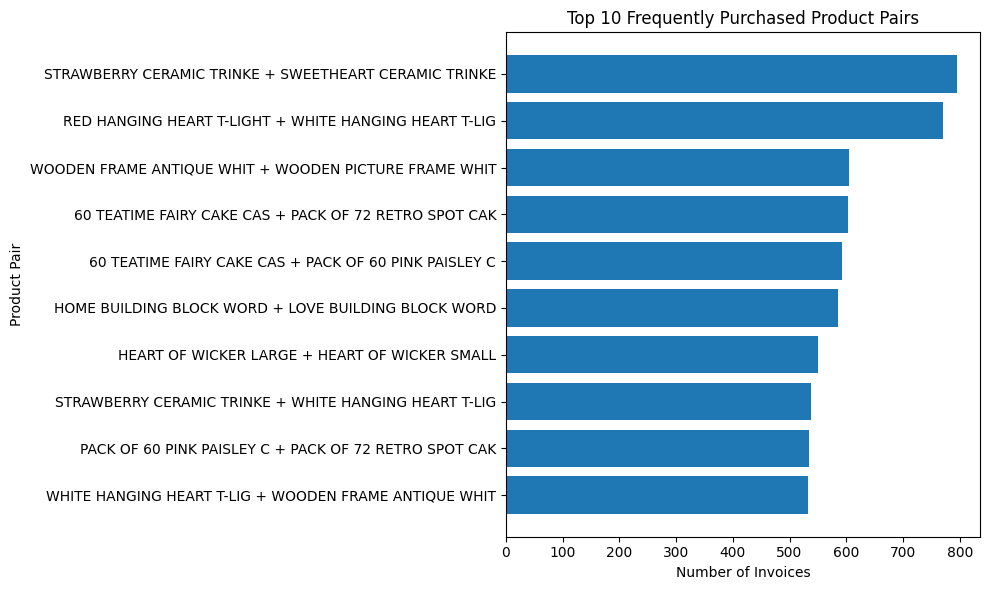

In [20]:
top_10 = top_pairs.head(10).copy()

top_10["Pair"] = (
    top_10["Product 1"].str[:25]
    + " + "
    + top_10["Product 2"].str[:25]
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    top_10["Pair"][::-1],
    top_10["Frequency"][::-1]
)

plt.xlabel("Number of Invoices")
plt.ylabel("Product Pair")
plt.title("Top 10 Frequently Purchased Product Pairs")

plt.tight_layout()
plt.show()

## 11. Key Insights


- The most frequently purchased product pair was STRAWBERRY CERAMIC TRINKET BOX and SWEETHEART CERAMIC TRINKET BOX, appearing together in 796 invoices.
- RED HANGING HEART T-LIGHT HOLDER and WHITE HANGING HEART T-LIGHT HOLDER were purchased together in 771 invoices.
- Several frequently purchased combinations contain related or complementary products.
- Product-pair frequency can be used to identify common customer purchasing patterns.
- These relationships can support cross-selling and product recommendation strategies.

## 12. Conclusion
Product Basket Analysis was performed using the Online Retail II dataset with Python and Pandas.

The analysis grouped products according to their Invoice IDs and identified frequently purchased product combinations.

The most frequent product pair was STRAWBERRY CERAMIC TRINKET BOX and SWEETHEART CERAMIC TRINKET BOX, which appeared together in 796 invoices.

The identified product relationships can be used to understand customer purchasing behavior and create simple product recommendations or cross-selling opportunities.